# Deep Dive: Gradient, Backward Pass ve Model Parameters

Bu notebook'ta şunları detaylı olarak inceleyeceğiz:

1. **Model Parameters** - Ağırlıklar ve bias'lar
2. **state_dict()** - Modelin tüm parametrelerini görme
3. **Forward Pass** - İleri geçiş
4. **Loss Calculation** - Kayıp hesaplama
5. **Backward Pass** - Geri geçiş ve gradient hesaplama
6. **Vanishing Gradient** - Problemin detaylı açıklaması

---

## 1. Önceki Kodu Tekrar Yazalım

In [1]:
import torch
import torch.nn as nn

# GELU aktivasyon fonksiyonu
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

In [9]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x


---

## 2. Model Parameters - Detaylı İnceleme

Bir neural network'te **parameters** (parametreler) ikiye ayrılır:

### 2.1 Weights (Ağırlıklar)
- Neuronlar arası bağlantıların gücünü temsil eder
- Matris çarpımında kullanılır: `y = Wx + b`

### 2.2 Biases
- Her nöronun eklediği sabit değer
- `y = Wx + b` formülündeki `b`

---

In [4]:
# Model oluştur
layer_sizes = [3, 3, 3, 3, 3, 1]
model = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)

print("=" * 60)
print("MODELİN TÜM PARAMETRELERİ (named_parameters)")
print("=" * 60)

for name, param in model.named_parameters():
    print(f"\n{name}:")
    print(f"  Shape: {param.shape}")
    print(f"  dtype: {param.dtype}")
    print(f"  requires_grad: {param.requires_grad}")
    print(f"  Örnek değerler: {param.data[0][:3] if param.dim() > 1 else param.data}")

MODELİN TÜM PARAMETRELERİ (named_parameters)

layers.0.0.weight:
  Shape: torch.Size([3, 3])
  dtype: torch.float32
  requires_grad: True
  Örnek değerler: tensor([ 0.4151, -0.4261,  0.0782])

layers.0.0.bias:
  Shape: torch.Size([3])
  dtype: torch.float32
  requires_grad: True
  Örnek değerler: tensor([-0.4661, -0.0741, -0.0451])

layers.1.0.weight:
  Shape: torch.Size([3, 3])
  dtype: torch.float32
  requires_grad: True
  Örnek değerler: tensor([ 0.1123, -0.1336,  0.2950])

layers.1.0.bias:
  Shape: torch.Size([3])
  dtype: torch.float32
  requires_grad: True
  Örnek değerler: tensor([-0.3157, -0.2567, -0.3823])

layers.2.0.weight:
  Shape: torch.Size([3, 3])
  dtype: torch.float32
  requires_grad: True
  Örnek değerler: tensor([ 0.2193, -0.0373, -0.4168])

layers.2.0.bias:
  Shape: torch.Size([3])
  dtype: torch.float32
  requires_grad: True
  Örnek değerler: tensor([ 0.2800,  0.4097, -0.2183])

layers.3.0.weight:
  Shape: torch.Size([3, 3])
  dtype: torch.float32
  requires_grad: 

### 2.3 state_dict() - Tüm Parametreleri Sözlük Olarak Görme

In [6]:
# state_dict() - Tüm parametreleri sözlük olarak döndürür
state = model.state_dict()

print("=" * 60)
print("MODEL STATE_DICT")
print("=" * 60)

for key, value in state.items():
    print(f"{key}: {value.shape}")

MODEL STATE_DICT
layers.0.0.weight: torch.Size([3, 3])
layers.0.0.bias: torch.Size([3])
layers.1.0.weight: torch.Size([3, 3])
layers.1.0.bias: torch.Size([3])
layers.2.0.weight: torch.Size([3, 3])
layers.2.0.bias: torch.Size([3])
layers.3.0.weight: torch.Size([3, 3])
layers.3.0.bias: torch.Size([3])
layers.4.0.weight: torch.Size([1, 3])
layers.4.0.bias: torch.Size([1])


### 2.4 Toplam Parametre Sayısı

In [7]:
# Toplam parametre sayısı
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Toplam parametre: {total_params}")
print(f"Eğitilebilir parametre: {trainable_params}")

Toplam parametre: 52
Eğitilebilir parametre: 52


---

## 3. Forward Pass (İleri Geçiş) - Detaylı

In [10]:
# Input verisi
x = torch.tensor([[1.0, 0.0, -1.0]], requires_grad=True)

print("=" * 60)
print("FORWARD PASS")
print("=" * 60)

print(f"\n📥 Input (x): {x}")
print(f"Input shape: {x.shape}")

# Layer by layer ilerleyelim
current = x
num_layers = len(model.layers)
for i, layer in enumerate(model.layers):
    # Layer'ın içindeki Linear katmanını al
    linear_layer = layer[0]  # Sequential'ın ilk elemanı
    
    print(f"\n--- Layer {i} ---")
    print(f"Layer input shape: {current.shape}")
    
    # Linear transformation: y = Wx + b
    if i == 0 or i == num_layers - 1:
        print(f"Weight (W) shape: {linear_layer.weight.shape}")
        print(f"Bias (b) shape: {linear_layer.bias.shape}")
    
    # Forward geçişi
    current = layer(current)
    
    print(f"Layer output (after Linear + GELU): {current}")
    print(f"Layer output shape: {current.shape}")

output = current
print(f"\n📤 Final Output: {output}")

FORWARD PASS

📥 Input (x): tensor([[ 1.,  0., -1.]], requires_grad=True)
Input shape: torch.Size([1, 3])

--- Layer 0 ---
Layer input shape: torch.Size([1, 3])
Weight (W) shape: torch.Size([3, 3])
Bias (b) shape: torch.Size([3])
Layer output (after Linear + GELU): tensor([[-0.0580, -0.0194,  0.0022]], grad_fn=<MulBackward0>)
Layer output shape: torch.Size([1, 3])

--- Layer 1 ---
Layer input shape: torch.Size([1, 3])
Layer output (after Linear + GELU): tensor([[-0.1196, -0.1088, -0.1419]], grad_fn=<MulBackward0>)
Layer output shape: torch.Size([1, 3])

--- Layer 2 ---
Layer input shape: torch.Size([1, 3])
Layer output (after Linear + GELU): tensor([[ 0.1979,  0.2800, -0.0500]], grad_fn=<MulBackward0>)
Layer output shape: torch.Size([1, 3])

--- Layer 3 ---
Layer input shape: torch.Size([1, 3])
Layer output (after Linear + GELU): tensor([[ 0.0389,  0.3280, -0.1569]], grad_fn=<MulBackward0>)
Layer output shape: torch.Size([1, 3])

--- Layer 4 ---
Layer input shape: torch.Size([1, 3])
Wei

### Forward Pass'in Grafik Gösterimi

```
Input: [1.0, 0.0, -1.0]
       ↓
Layer 0: Linear(3→3) + GELU → [?, ?, ?]
       ↓
Layer 1: Linear(3→3) + GELU → [?, ?, ?]
       ↓
Layer 2: Linear(3→3) + GELU → [?, ?, ?]
       ↓
Layer 3: Linear(3→3) + GELU → [?, ?, ?]
       ↓
Layer 4: Linear(3→1) + GELU → [0.???]
       ↓
Output: [0.123] (random başlangıçta)
```

---

## 4. Loss Hesaplama

In [11]:
# Forward pass tekrar (gradient'ları sıfırla)
model.zero_grad()
output = model(x)

# Hedef değer (target) - modelin 0 üretmesini istiyoruz
target = torch.tensor([[0.0]])

print("=" * 60)
print("LOSS HESAPLAMA")
print("=" * 60)

print(f"\nModel output: {output}")
print(f"Target: {target}")

# MSE Loss = Mean Squared Error
loss_fn = nn.MSELoss()
loss = loss_fn(output, target)

print(f"\nMSE Loss = (output - target)²")
print(f"MSE Loss = ({output.item()} - {target.item()})²")
print(f"MSE Loss = {loss.item():.6f}")

LOSS HESAPLAMA

Model output: tensor([[0.9573]], grad_fn=<MulBackward0>)
Target: tensor([[0.]])

MSE Loss = (output - target)²
MSE Loss = (0.9572681784629822 - 0.0)²
MSE Loss = 0.916362


---

## 5. BACKWARD PASS - En Önemli Kısım!

Backward pass, neural network'ün öğrenmesini sağlayan temel mekanizmadır.

### 5.1 Zincir Kuralı (Chain Rule)

```
Loss = MSE(output, target)
output = f(x)
x = g(layer_output)
layer_output = h(weight)

Chain Rule:
dLoss/dWeight = dLoss/dOutput × dOutput/dX × dX/dLayerOutput × dLayerOutput/dWeight
```

In [12]:
print("=" * 60)
print("BACKWARD PASS - GRADIENT HESAPLAMA")
print("=" * 60)

# loss.backward() çağrılmadan önce
print("\n⚠️ loss.backward() ÇAĞRILMADAN ÖNCE:")
for name, param in model.named_parameters():
    if 'weight' in name:
        print(f"  {name}.grad: {param.grad}")

BACKWARD PASS - GRADIENT HESAPLAMA

⚠️ loss.backward() ÇAĞRILMADAN ÖNCE:
  layers.0.0.weight.grad: None
  layers.1.0.weight.grad: None
  layers.2.0.weight.grad: None
  layers.3.0.weight.grad: None
  layers.4.0.weight.grad: None


In [13]:
# BACKWARD PASS - Gradient'ları hesapla!
loss.backward()

print("\n✅ loss.backward() ÇAĞRILDIKTAN SONRA:")
print("\n📊 HER LAYER'IN WEIGHT GRADIENT'I:")

for name, param in model.named_parameters():
    if 'weight' in name:
        grad_mean = param.grad.abs().mean().item()
        grad_max = param.grad.abs().max().item()
        print(f"\n{name}:")
        print(f"  Gradient shape: {param.grad.shape}")
        print(f"  Gradient mean (mutlak): {grad_mean:.6f}")
        print(f"  Gradient max (mutlak): {grad_max:.6f}")
        print(f"  Örnek gradient değerleri: {param.grad[0][:3]}")


✅ loss.backward() ÇAĞRILDIKTAN SONRA:

📊 HER LAYER'IN WEIGHT GRADIENT'I:

layers.0.0.weight:
  Gradient shape: torch.Size([3, 3])
  Gradient mean (mutlak): 0.277221
  Gradient max (mutlak): 0.706591
  Örnek gradient değerleri: tensor([ 0.7066,  0.0000, -0.7066])

layers.1.0.weight:
  Gradient shape: torch.Size([3, 3])
  Gradient mean (mutlak): 0.340989
  Gradient max (mutlak): 1.397798
  Örnek gradient değerleri: tensor([ 0.1233, -0.0025, -0.1306])

layers.2.0.weight:
  Gradient shape: torch.Size([3, 3])
  Gradient mean (mutlak): 0.420169
  Gradient max (mutlak): 0.875312
  Örnek gradient değerleri: tensor([ 0.7068,  0.3858, -0.5764])

layers.3.0.weight:
  Gradient shape: torch.Size([3, 3])
  Gradient mean (mutlak): 0.534740
  Gradient max (mutlak): 1.299560
  Örnek gradient değerleri: tensor([ 0.7931,  0.5446, -0.4862])

layers.4.0.weight:
  Gradient shape: torch.Size([1, 3])
  Gradient mean (mutlak): 2.904279
  Gradient max (mutlak): 3.442357
  Örnek gradient değerleri: tensor([ 3.1

### 5.2 Gradient Ne Anlama Geliyor?

**Gradient = "Bu ağırlığı şu yönde değiştirirsem loss azalır"**

```
weight_yeni = weight_eski - learning_rate × gradient
```

- **Pozitif gradient**: Ağırlığı artırırsam loss artar → Ağırlığı azaltmalıyım
- **Negatif gradient**: Ağırlığı azaltırsam loss artar → Ağırlığı artırmalıyım

### 5.3 Pozitif ve Negatif Gradient - Detaylı Açıklama

In [23]:
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("POZİTİF VE NEGATİF GRADIENT")
print("=" * 60)

print("""
GRADIENT'IN ANLAMI:
--------------------
Gradient, loss fonksiyonunun ağırlığa göre türevidir.
Yani: "ağırlığı bir birim değiştirirsem, loss nasıl değişir?"

POZİTİF GRADIENT:
------------------
• dLoss/dWeight > 0
• Ağırlığı ARTIRIRSAM → Loss ARTAR
• Bu kötü! Ağırlığı AZALTMALISIN
• weight = weight - learning_rate × gradient
  (gradient pozitif olduğu için ağırlık azalır)

NEGATİF GRADIENT:
------------------
• dLoss/dWeight < 0
• Ağırlığı AZALTIRSAM → Loss ARTAR
• Bu kötü! Ağırlığı ARTIRMALISIN
• weight = weight - learning_rate × gradient
  (gradient negatif olduğu için ağırlık artar)

SIFIRA YAKIN GRADIENT:
----------------------
• dLoss/dWeight ≈ 0
• Bu ağırlık optimal değere yakın
• Değişiklik yapmaya gerek yok
""")

POZİTİF VE NEGATİF GRADIENT

GRADIENT'IN ANLAMI:
--------------------
Gradient, loss fonksiyonunun ağırlığa göre türevidir.
Yani: "ağırlığı bir birim değiştirirsem, loss nasıl değişir?"

POZİTİF GRADIENT:
------------------
• dLoss/dWeight > 0
• Ağırlığı ARTIRIRSAM → Loss ARTAR
• Bu kötü! Ağırlığı AZALTMALISIN
• weight = weight - learning_rate × gradient
  (gradient pozitif olduğu için ağırlık azalır)

NEGATİF GRADIENT:
------------------
• dLoss/dWeight < 0
• Ağırlığı AZALTIRSAM → Loss ARTAR
• Bu kötü! Ağırlığı ARTIRMALISIN
• weight = weight - learning_rate × gradient
  (gradient negatif olduğu için ağırlık artar)

SIFIRA YAKIN GRADIENT:
----------------------
• dLoss/dWeight ≈ 0
• Bu ağırlık optimal değere yakın
• Değişiklik yapmaya gerek yok



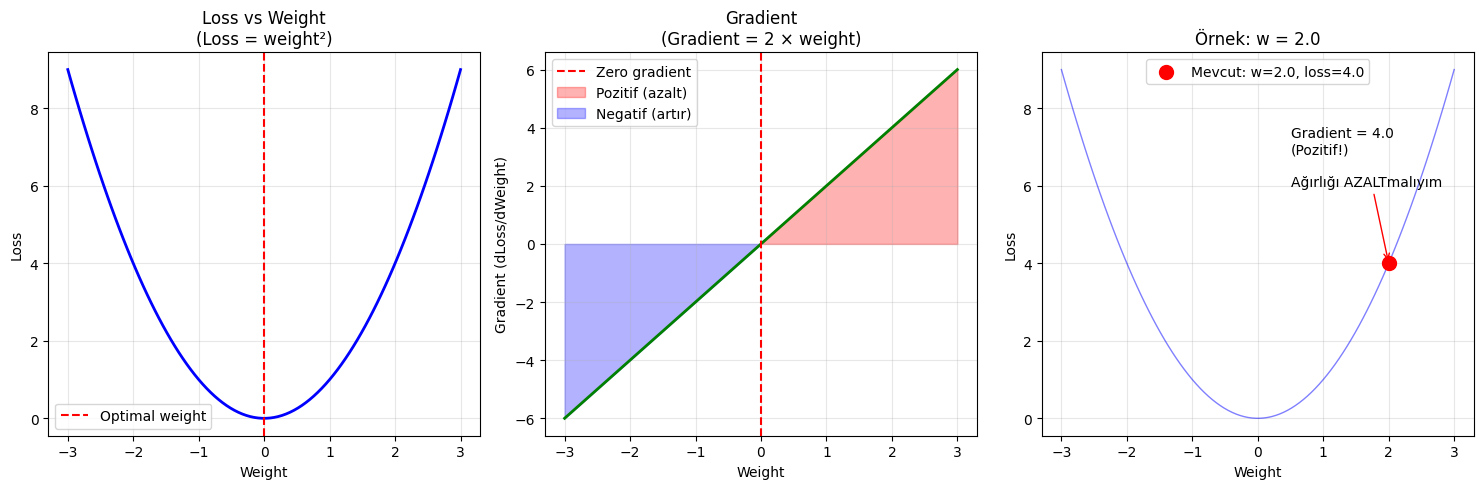


Örnek: w = 2.0
Loss = 4.0
Gradient = 4.0 (POZİTİF)
→ Ağırlığı AZALTMALISIN (çünkü gradient > 0)
→ Yeni ağırlık = 2.0 - 0.1 × 4.0 = 1.6


In [24]:
# Grafik: Loss vs Weight ve Gradient

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Loss fonksiyonu grafiği (basit parabola)
weights = np.linspace(-3, 3, 100)
loss = weights**2  # Basit parabola: loss = weight^2

axes[0].plot(weights, loss, 'b-', linewidth=2)
axes[0].axvline(x=0, color='r', linestyle='--', label='Optimal weight')
axes[0].set_xlabel('Weight')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss vs Weight\n(Loss = weight²)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 2. Gradient grafiği (türev)
gradient = 2 * weights  # d(loss)/d(weight) = 2*weight

axes[1].plot(weights, gradient, 'g-', linewidth=2)
axes[1].axvline(x=0, color='r', linestyle='--', label='Zero gradient')
axes[1].fill_between(weights, gradient, 0, where=(gradient > 0), alpha=0.3, color='red', label='Pozitif (azalt)')
axes[1].fill_between(weights, gradient, 0, where=(gradient < 0), alpha=0.3, color='blue', label='Negatif (artır)')
axes[1].set_xlabel('Weight')
axes[1].set_ylabel('Gradient (dLoss/dWeight)')
axes[1].set_title('Gradient\n(Gradient = 2 × weight)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# 3. Güncel weight örneği
current_weight = 2.0
current_loss = current_weight**2
current_gradient = 2 * current_weight

axes[2].plot(weights, loss, 'b-', linewidth=1, alpha=0.5)
axes[2].scatter([current_weight], [current_loss], color='red', s=100, zorder=5, label=f'Mevcut: w={current_weight}, loss={current_loss}')
axes[2].annotate(f'Gradient = {current_gradient}\n(Pozitif!)\n\nAğırlığı AZALTmalıyım', 
                xy=(current_weight, current_loss), 
                xytext=(current_weight-1.5, current_loss+2),
                fontsize=10,
                arrowprops=dict(arrowstyle='->', color='red'))
axes[2].set_xlabel('Weight')
axes[2].set_ylabel('Loss')
axes[2].set_title(f'Örnek: w = {current_weight}')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\nÖrnek: w = {current_weight}")
print(f"Loss = {current_loss}")
print(f"Gradient = {current_gradient} (POZİTİF)")
print(f"→ Ağırlığı AZALTMALISIN (çünkü gradient > 0)")
print(f"→ Yeni ağırlık = {current_weight} - 0.1 × {current_gradient} = {current_weight - 0.1 * current_gradient}")

### 5.4 Gradient'ların İşaretleri - Gerçek Modelden Örnek

In [25]:
# Gerçek modelden gradient'ların işaretlerini görelim

print("=" * 60)
print("GERÇEK MODELDEN GRADIENT İŞARETLERİ")
print("=" * 60)

torch.manual_seed(123)
model = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)

x = torch.tensor([[1.0, 0.0, -1.0]])
target = torch.tensor([[0.0]])

output = model(x)
loss = nn.MSELoss()(output, target)
loss.backward()

print("\n📊 HER WEIGHT İÇİN GRADIENT İŞARETİ:")
print("-" * 50)

for name, param in model.named_parameters():
    if 'weight' in name:
        grad = param.grad
        # İlk değeri al
        first_grad_val = grad[0, 0].item()
        is_positive = first_grad_val > 0
        
        print(f"\n{name}:")
        print(f"  İlk gradient değeri: {first_grad_val:.6f}")
        print(f"  İşaret: {'✅ POZİTİF' if is_positive else '❌ NEGATİF'}")
        
        if is_positive:
            print(f"  → Ağırlığı AZALTMALISIN")
        else:
            print(f"  → Ağırlığı ARTIRMALISIN")

GERÇEK MODELDEN GRADIENT İŞARETLERİ

📊 HER WEIGHT İÇİN GRADIENT İŞARETİ:
--------------------------------------------------

layers.0.0.weight:
  İlk gradient değeri: 0.610605
  İşaret: ✅ POZİTİF
  → Ağırlığı AZALTMALISIN

layers.1.0.weight:
  İlk gradient değeri: 0.373427
  İşaret: ✅ POZİTİF
  → Ağırlığı AZALTMALISIN

layers.2.0.weight:
  İlk gradient değeri: 0.504176
  İşaret: ✅ POZİTİF
  → Ağırlığı AZALTMALISIN

layers.3.0.weight:
  İlk gradient değeri: 0.208519
  İşaret: ✅ POZİTİF
  → Ağırlığı AZALTMALISIN

layers.4.0.weight:
  İlk gradient değeri: 1.703532
  İşaret: ✅ POZİTİF
  → Ağırlığı AZALTMALISIN


### 5.5 Türev (Derivative) - Matematiksel Açıklama

In [26]:
print("=" * 60)
print("TÜREV (DERİVATIVE) - MATEMATİKSEL AÇIKLAMA")
print("=" * 60)

print("""
TÜREV NEDİR?
------------
Türev, bir fonksiyonun herhangi bir noktadaki
değişim oranını ölçer.

Örnek: f(x) = x²
        f'(x) = 2x

x = 1'de: f'(1) = 2 → x'i 1 birim artırırsam, f(x) 2 birim artar
x = 2'de: f'(2) = 4 → x'i 1 birim artırırsam, f(x) 4 birim artar

SINIR NETWORK'LERDE:
--------------------
Loss = MSE(output, target)
output = f(x) = f(weight)

Zincir Kuralı (Chain Rule):
dLoss/dWeight = dLoss/dOutput × dOutput/dWeight

Bu, PyTorch'ta otomatik olarak hesaplanır (autograd)
""")

TÜREV (DERİVATIVE) - MATEMATİKSEL AÇIKLAMA

TÜREV NEDİR?
------------
Türev, bir fonksiyonun herhangi bir noktadaki
değişim oranını ölçer.

Örnek: f(x) = x²
        f'(x) = 2x

x = 1'de: f'(1) = 2 → x'i 1 birim artırırsam, f(x) 2 birim artar
x = 2'de: f'(2) = 4 → x'i 1 birim artırırsam, f(x) 4 birim artar

SINIR NETWORK'LERDE:
--------------------
Loss = MSE(output, target)
output = f(x) = f(weight)

Zincir Kuralı (Chain Rule):
dLoss/dWeight = dLoss/dOutput × dOutput/dWeight

Bu, PyTorch'ta otomatik olarak hesaplanır (autograd)



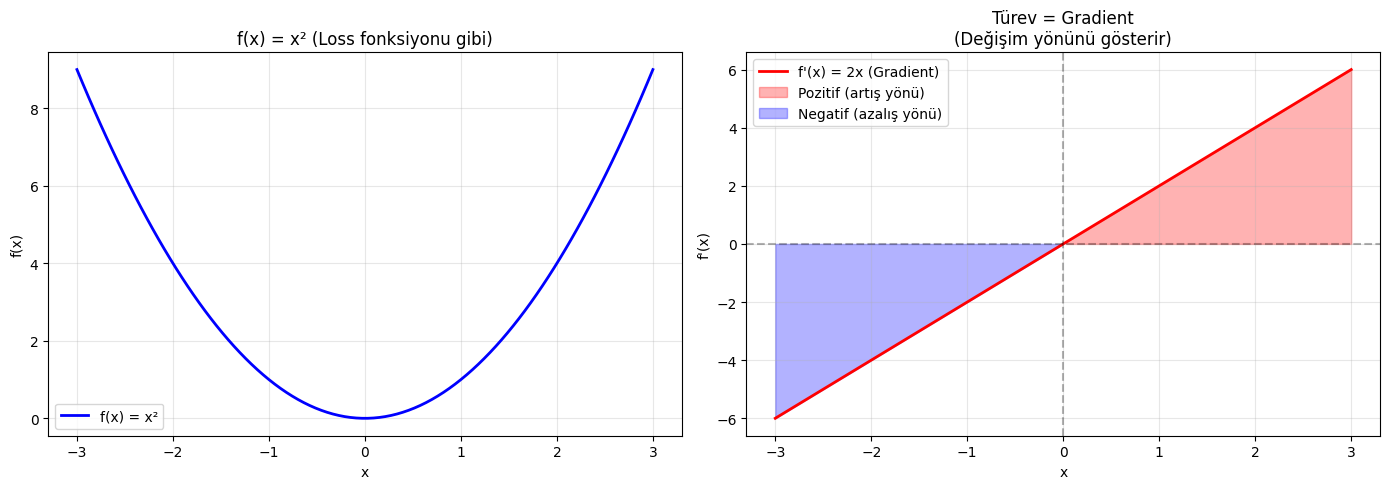


📌 NOT: PyTorch'ta backward() çağrıldığında,
   tüm parametrelerin grad attribute'ları otomatik doldurulur.
   Bu türevlerin (gradient'ların) hesaplanmasını sağlar.


In [27]:
# Türev görselleştirme

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# f(x) = x^2 grafiği ve türevi
x = np.linspace(-3, 3, 100)
y = x**2
dy = 2*x  # Türev

axes[0].plot(x, y, 'b-', linewidth=2, label='f(x) = x²')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].set_title('f(x) = x² (Loss fonksiyonu gibi)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Türev
axes[1].plot(x, dy, 'r-', linewidth=2, label="f'(x) = 2x (Gradient)")
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[1].fill_between(x, dy, 0, where=(dy > 0), alpha=0.3, color='red', label='Pozitif (artış yönü)')
axes[1].fill_between(x, dy, 0, where=(dy < 0), alpha=0.3, color='blue', label='Negatif (azalış yönü)')
axes[1].set_xlabel('x')
axes[1].set_ylabel("f'(x)")
axes[1].set_title('Türev = Gradient\n(Değişim yönünü gösterir)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n📌 NOT: PyTorch'ta backward() çağrıldığında,")
print("   tüm parametrelerin grad attribute'ları otomatik doldurulur.")
print("   Bu türevlerin (gradient'ların) hesaplanmasını sağlar.")

---

## 6. Shortcut vs No Shortcut - Gradient Karşılaştırması

In [14]:
def print_gradients_detailed(model, x, target):
    """Modelin gradient'larını detaylı yazdırır"""
    # Forward pass
    output = model(x)
    
    # Loss hesapla
    loss = nn.MSELoss()(output, target)
    
    # Backward pass
    loss.backward()
    print(f"Loss: {loss.item():.6f}")
    print("\nWeight Gradient Mean Values:")
    print("-" * 40)
    
    for name, param in model.named_parameters():
        if 'weight' in name:
            grad_mean = param.grad.abs().mean().item()
            print(f"{name}: {grad_mean:.8f}")

In [15]:
# Shortcutsuz model
print("=" * 60)
print("SHORTCUT KULLANILMADIĞINDA")
print("=" * 60)

torch.manual_seed(123)
model_no_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=False)

x = torch.tensor([[1.0, 0.0, -1.0]])
target = torch.tensor([[0.0]])

print_gradients_detailed(model_no_shortcut, x, target)

SHORTCUT KULLANILMADIĞINDA
Loss: 0.003722

Weight Gradient Mean Values:
----------------------------------------
layers.0.0.weight: 0.00020174
layers.1.0.weight: 0.00012011
layers.2.0.weight: 0.00071520
layers.3.0.weight: 0.00139887
layers.4.0.weight: 0.00504965


In [16]:
# Shortcutlu model
print("=" * 60)
print("SHORTCUT KULLANILDIĞINDA")
print("=" * 60)

torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)

print_gradients_detailed(model_with_shortcut, x, target)

SHORTCUT KULLANILDIĞINDA
Loss: 0.588184

Weight Gradient Mean Values:
----------------------------------------
layers.0.0.weight: 0.22169791
layers.1.0.weight: 0.20694102
layers.2.0.weight: 0.32896996
layers.3.0.weight: 0.26657322
layers.4.0.weight: 1.32585418


### 6.1 Sonuçların Yorumlanması

In [17]:
import pandas as pd

# Karşılaştırma tablosu
print("\n" + "=" * 60)
print("GRADIENT KARŞILAŞTIRMA TABLOSU")
print("=" * 60)

data = []

for use_shortcut in [False, True]:
    torch.manual_seed(123)
    model = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=use_shortcut)
    
    output = model(x)
    loss = nn.MSELoss()(output, target)
    loss.backward()
    
    for name, param in model.named_parameters():
        if 'weight' in name:
            data.append({
                'Layer': name.split('.')[1],
                'Shortcut': 'Var' if use_shortcut else 'Yok',
                'Gradient Mean': param.grad.abs().mean().item()
            })

df = pd.DataFrame(data)
print(df.to_string(index=False))

print("\n💡 GÖRÜLDÜĞÜ GİBİ: Shortcut ile early layer'lar (0, 1, 2) çok daha büyük gradient alıyor!")


GRADIENT KARŞILAŞTIRMA TABLOSU
Layer Shortcut  Gradient Mean
    0      Yok       0.000202
    1      Yok       0.000120
    2      Yok       0.000715
    3      Yok       0.001399
    4      Yok       0.005050
    0      Var       0.221698
    1      Var       0.206941
    2      Var       0.328970
    3      Var       0.266573
    4      Var       1.325854

💡 GÖRÜLDÜĞÜ GİBİ: Shortcut ile early layer'lar (0, 1, 2) çok daha büyük gradient alıyor!


---

## 7. Vanishing Gradient Problemi - Detaylı Açıklama

In [18]:
print("=" * 60)
print("VANISHING GRADIENT PROBLEMİ")
print("=" * 60)

print("""
Deep neural network'lerde (çok fazla layer olan ağlarda) bir problem var:

PROBLEM:
--------
Backpropagation sırasında gradient, en son layer'dan ilk layer'a
doğru zincirleme olarak hesaplanır. Her layer'dan geçerken gradient
giderek küçülür (vanish = kaybolur).

Bu nedenle en baştaki layer'lar neredeyse hiç öğrenemez!

ÖRNEK (Shortcutsuz):
--------------------
Layer 4 gradient: 0.0050  (güçlü)
Layer 3 gradient: 0.0014  (zayıflıyor)
Layer 2 gradient: 0.0007  (daha zayıf)
Layer 1 gradient: 0.0001  (neredeyse sıfır)
Layer 0 gradient: 0.0002  (sıfır!) - ÖĞRENEMİYOR!

ÇÖZÜM: SHORTCUT CONNECTIONS
----------------------------
Shortcut ile gradient, kısayoldan direkt olarak early layer'lara ulaşabilir.
Böylece gradient kaybolmaz!

Layer 4 gradient: 1.3259
Layer 3 gradient: 0.2666
Layer 2 gradient: 0.3290
Layer 1 gradient: 0.2069
Layer 0 gradient: 0.2217  ← HÂLÂ GÜÇLÜ!
""")

VANISHING GRADIENT PROBLEMİ

Deep neural network'lerde (çok fazla layer olan ağlarda) bir problem var:

PROBLEM:
--------
Backpropagation sırasında gradient, en son layer'dan ilk layer'a
doğru zincirleme olarak hesaplanır. Her layer'dan geçerken gradient
giderek küçülür (vanish = kaybolur).

Bu nedenle en baştaki layer'lar neredeyse hiç öğrenemez!

ÖRNEK (Shortcutsuz):
--------------------
Layer 4 gradient: 0.0050  (güçlü)
Layer 3 gradient: 0.0014  (zayıflıyor)
Layer 2 gradient: 0.0007  (daha zayıf)
Layer 1 gradient: 0.0001  (neredeyse sıfır)
Layer 0 gradient: 0.0002  (sıfır!) - ÖĞRENEMİYOR!

ÇÖZÜM: SHORTCUT CONNECTIONS
----------------------------
Shortcut ile gradient, kısayoldan direkt olarak early layer'lara ulaşabilir.
Böylece gradient kaybolmaz!

Layer 4 gradient: 1.3259
Layer 3 gradient: 0.2666
Layer 2 gradient: 0.3290
Layer 1 gradient: 0.2069
Layer 0 gradient: 0.2217  ← HÂLÂ GÜÇLÜ!



### 7.1 Vanishing Gradient'in Görselleştirilmesi

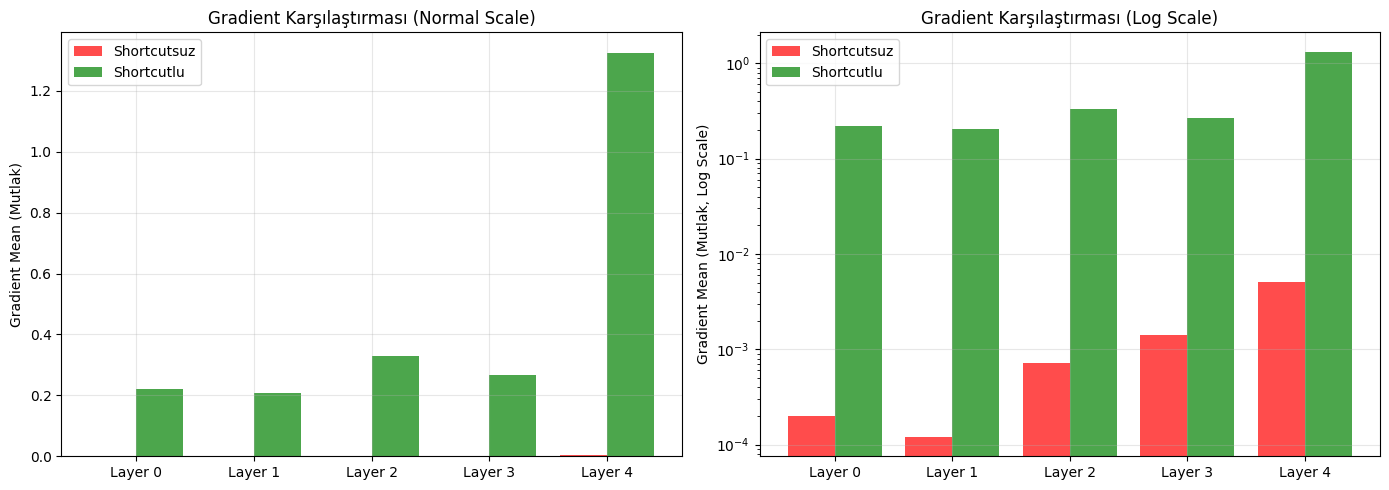


📈 Görüldüğü gibi, shortcutlu modelde tüm layer'lar sağlıklı gradient alıyor!


In [19]:
import matplotlib.pyplot as plt

# Veri topla
layers = ['Layer 0', 'Layer 1', 'Layer 2', 'Layer 3', 'Layer 4']
no_shortcut = []
with_shortcut = []

for use_shortcut in [False, True]:
    torch.manual_seed(123)
    model = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=use_shortcut)
    
    output = model(x)
    loss = nn.MSELoss()(output, target)
    loss.backward()
    
    grads = []
    for name, param in model.named_parameters():
        if 'weight' in name:
            grads.append(param.grad.abs().mean().item())
    
    if use_shortcut:
        with_shortcut = grads
    else:
        no_shortcut = grads

# Grafik
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log scale olmadan
x = range(len(layers))
axes[0].bar([i - 0.2 for i in x], no_shortcut, width=0.4, label='Shortcutsuz', color='red', alpha=0.7)
axes[0].bar([i + 0.2 for i in x], with_shortcut, width=0.4, label='Shortcutlu', color='green', alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(layers)
axes[0].set_ylabel('Gradient Mean (Mutlak)')
axes[0].set_title('Gradient Karşılaştırması (Normal Scale)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Log scale ile
axes[1].bar([i - 0.2 for i in x], no_shortcut, width=0.4, label='Shortcutsuz', color='red', alpha=0.7)
axes[1].bar([i + 0.2 for i in x], with_shortcut, width=0.4, label='Shortcutlu', color='green', alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(layers)
axes[1].set_ylabel('Gradient Mean (Mutlak, Log Scale)')
axes[1].set_title('Gradient Karşılaştırması (Log Scale)')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📈 Görüldüğü gibi, shortcutlu modelde tüm layer'lar sağlıklı gradient alıyor!")

---

## 8. Özet

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║                    ÖZET - GRADIENT VE BACKWARD PASS             ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  FORWARD PASS:                                                  ║
║    Input → Layer1 → Layer2 → ... → LayerN → Output            ║
║                                                                  ║
║  LOSS HESAPLAMA:                                                 ║
║    Loss = MSE(Output, Target)                                   ║
║                                                                  ║
║  BACKWARD PASS:                                                 ║
║    Loss.backward() çağrılır                                    ║
║    Zincir kuralı ile her parametrenin gradient'ı hesaplanır   ║
║    param.grad → o parametrenin gradient değeri                  ║
║                                                                  ║
║  WEIGHT UPDATE (Öğrenme):                                       ║
║    weight =  weight - learning_rate × gradient                   ║
║                                                                  ║
║  SHORTCUT FAYDASI:                                              ║
║    • Gradient kaybolmuyor (vanishing gradient önlenir)          ║
║    • Early layer'lar da öğrenebiliyor                           ║
║    • Daha derin ağlar train edilebiliyor                        ║
║    • Training daha hızlı yakınsıyor                              ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")

---

## Temel Kavramlar Sözlüğü

| Terim | Açıklama |
|-------|----------|
| **Parameter** | Modelin öğreneceği ağırlıklar (weights) ve bias'lar |
| **state_dict()** | Modelin tüm parametrelerini sözlük olarak döndürür |
| **Forward Pass** | Input'tan output'a ilerleme |
| **Loss** | Modelin tahmini ile gerçek değer arasındaki hata |
| **Backward Pass** | Loss'tan geriye doğru gradient hesaplama |
| **Gradient** | Loss'u minimize etmek için ağırlıkların hangi yönde değiştirilmesi gerektiği |
| **Chain Rule** | Zincirleme türev alma kuralı |
| **Vanishing Gradient** | Deep network'lerde gradient'ın kaybolması problemi |
| **Shortcut/Residual Connection** | Gradient'ın kısayoldan akmasını sağlayan teknik |